In [13]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True

In [14]:
INPUT_PATH = Path(r"C:\Users\Lutfi\Documents\Project\AITF\rutilahu-vlm-etl\metadata\mkn2_metadata_final.json")
OUTPUT_DIR = Path(r"C:\Users\Lutfi\Documents\Project\AITF\rutilahu-vlm-etl\metadata_sample\eda_mkn2")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [15]:
INPUT_PATH, OUTPUT_DIR

(WindowsPath('C:/Users/Lutfi/Documents/Project/AITF/rutilahu-vlm-etl/metadata/mkn2_metadata_final.json'),
 WindowsPath('C:/Users/Lutfi/Documents/Project/AITF/rutilahu-vlm-etl/metadata_sample/eda_mkn2'))

In [16]:
with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

len(data), type(data)

(14861, list)

In [17]:
def norm_text(value):
    if value is None:
        return None
    text = str(value).strip()
    return text if text else None

def norm_label(value):
    if value is None:
        return None
    text = str(value).strip()
    if not text:
        return None
    if text.lower() == "tidak terdeteksi":
        return "Tidak terdeteksi"
    return text

In [18]:
rows = []
for rec in data:
    actual = rec.get("actual_label", {}) or {}
    dtsen = rec.get("dtsen", {}) or {}
    status = rec.get("status", {}) or {}

    rows.append({
        "house_id": rec.get("house_id"),
        "no_kk": rec.get("no_kk"),
        "house_type": norm_text(rec.get("house_type")),
        "split": norm_text(rec.get("split")),
        "image_count": len(rec.get("images", [])) if isinstance(rec.get("images", []), list) else 0,
        "actual_atap": norm_label(actual.get("atap")),
        "actual_dinding": norm_label(actual.get("dinding")),
        "actual_lantai": norm_label(actual.get("lantai")),
        "dtsen_atap": norm_label(dtsen.get("atap")),
        "dtsen_dinding": norm_label(dtsen.get("dinding")),
        "dtsen_lantai": norm_label(dtsen.get("lantai")),
        "status_atap": norm_text(status.get("atap")),
        "status_dinding": norm_text(status.get("dinding")),
        "status_lantai": norm_text(status.get("lantai")),
    })

df = pd.DataFrame(rows)
df.head()


,house_id,no_kk,house_type,split,image_count,actual_atap,actual_dinding,actual_lantai,dtsen_atap,dtsen_dinding,dtsen_lantai,status_atap,status_dinding,status_lantai
0,H00008,FAM_2337e64c97ac43347e115bf751cfa460f0de588139...,multi,None,2,Tidak terdeteksi,Tembok,Ubin/tegel/teraso,None,None,None,None,None,None
1,H00011,FAM_5cee826af6afc88a7ca77271c8782622a9406bff05...,multi,None,2,Genteng,Tembok,Semen/bata merah,None,None,None,None,None,None
2,H00014,FAM_0d790f54346c7c2d2402ffa6818dedfd8bfb94cafd...,multi,None,2,Asbes,Tembok,Semen/bata merah,None,None,None,None,None,None
3,H00024,FAM_b100abd680ca1dfd29d702dc3c6d426a5ae0ee7482...,multi,None,2,Genteng,Tembok,Keramik,None,None,None,None,None,None
4,H00033,FAM_23c2332ea34b2175a83f28decd08346b41484443cb...,multi,None,2,Asbes,Tembok,Semen/bata merah,None,None,None,None,None,None


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14861 entries, 0 to 14860
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   house_id        14861 non-null  object
 1   no_kk           10335 non-null  object
 2   house_type      14861 non-null  object
 3   split           5858 non-null   object
 4   image_count     14861 non-null  int64 
 5   actual_atap     14861 non-null  object
 6   actual_dinding  14861 non-null  object
 7   actual_lantai   14861 non-null  object
 8   dtsen_atap      5858 non-null   object
 9   dtsen_dinding   5858 non-null   object
 10  dtsen_lantai    5858 non-null   object
 11  status_atap     5858 non-null   object
 12  status_dinding  5858 non-null   object
 13  status_lantai   5858 non-null   object
dtypes: int64(1), object(13)
memory usage: 1.6+ MB


In [20]:
summary = {
    "total_records": len(df),
    "split_distribution": df["split"].value_counts(dropna=False).to_dict(),
    "house_type_distribution": df["house_type"].value_counts(dropna=False).to_dict(),
    "image_count_distribution": df["image_count"].value_counts(dropna=False).to_dict(),
}
summary

{'total_records': 14861,
 'split_distribution': {None: 9003, 'train': 4667, 'val': 598, 'test': 593},
 'house_type_distribution': {'multi': 7156,
  'single_exterior_only': 3932,
  'single_interior_only': 3773},
 'image_count_distribution': {1: 7704, 2: 7136, 4: 21}}

In [21]:
def count_distribution(series):
    return series.fillna("NaN").astype(str).value_counts(dropna=False).to_dict()

def distribution_by_split(df, col):
    out = {}
    for split in ["train", "val", "test"]:
        part = df[df["split"] == split]
        out[split] = count_distribution(part[col]) if not part.empty else {}
    return out

def combo_distribution_by_split(df, col):
    out = {}
    for split in ["train", "val", "test"]:
        part = df[df["split"] == split]
        out[split] = count_distribution(part[col]) if not part.empty else {}
    return out

df["actual_combo"] = df.apply(lambda r: f"{r['actual_atap']}||{r['actual_dinding']}||{r['actual_lantai']}", axis=1)
df["dtsen_combo"] = df.apply(lambda r: f"{r['dtsen_atap']}||{r['dtsen_dinding']}||{r['dtsen_lantai']}", axis=1)


In [22]:
split_distribution = count_distribution(df["split"])
house_type_distribution_by_split = distribution_by_split(df, "house_type")

actual_label_global = {
    "atap": count_distribution(df["actual_atap"]),
    "dinding": count_distribution(df["actual_dinding"]),
    "lantai": count_distribution(df["actual_lantai"]),
}

actual_label_by_split = {
    "atap": distribution_by_split(df, "actual_atap"),
    "dinding": distribution_by_split(df, "actual_dinding"),
    "lantai": distribution_by_split(df, "actual_lantai"),
}

dtsen_label_global = {
    "atap": count_distribution(df["dtsen_atap"]),
    "dinding": count_distribution(df["dtsen_dinding"]),
    "lantai": count_distribution(df["dtsen_lantai"]),
}

dtsen_label_by_split = {
    "atap": distribution_by_split(df, "dtsen_atap"),
    "dinding": distribution_by_split(df, "dtsen_dinding"),
    "lantai": distribution_by_split(df, "dtsen_lantai"),
}

status_distribution_by_split = {
    "atap": distribution_by_split(df, "status_atap"),
    "dinding": distribution_by_split(df, "status_dinding"),
    "lantai": distribution_by_split(df, "status_lantai"),
}

actual_combo_by_split = combo_distribution_by_split(df, "actual_combo")
dtsen_combo_by_split = combo_distribution_by_split(df, "dtsen_combo")


In [23]:
print("Split distribution:")
display(split_distribution)

print("\nHouse type distribution by split:")
display(house_type_distribution_by_split)

print("\nActual label global distribution:")
display(actual_label_global)

print("\nDTSEN global distribution:")
display(dtsen_label_global)

print("\nStatus distribution by split:")
display(status_distribution_by_split)

Split distribution:


{'NaN': 9003, 'train': 4667, 'val': 598, 'test': 593}


House type distribution by split:


{'train': {'multi': 2680,
  'single_exterior_only': 995,
  'single_interior_only': 992},
 'val': {'multi': 344,
  'single_exterior_only': 129,
  'single_interior_only': 125},
 'test': {'multi': 341,
  'single_exterior_only': 129,
  'single_interior_only': 123}}


Actual label global distribution:


{'atap': {'Tidak terdeteksi': 6947,
  'Genteng': 3594,
  'Asbes': 1602,
  'Seng': 967,
  'Jerami/ijuk/daun-daunan/rumbia': 685,
  'Kayu/sirap': 524,
  'Beton': 507,
  'Bambu': 19,
  'Lainnya': 16},
 'dinding': {'Tembok': 8108,
  'Tidak terdeteksi': 4040,
  'Kayu/papan/gypsum/GRC/calciboard': 1459,
  'Anyaman bambu': 725,
  'Batang kayu': 334,
  'Bambu': 162,
  'Plesteran anyaman bambu/kawat': 21,
  'Lainnya': 12},
 'lantai': {'Tidak terdeteksi': 4474,
  'Keramik': 4067,
  'Semen/bata merah': 2794,
  'Parket/vinil/karpet': 1273,
  'Marmer/granit': 990,
  'Tanah': 521,
  'Ubin/tegel/teraso': 428,
  'Kayu/papan': 301,
  'Lainnya': 8,
  'Bambu': 5}}


DTSEN global distribution:


{'atap': {'NaN': 9003,
  'Tidak terdeteksi': 1968,
  'Genteng': 1531,
  'Asbes': 694,
  'Seng': 490,
  'Beton': 310,
  'Kayu/sirap': 237,
  'Bambu': 217,
  'Lainnya': 208,
  'Jerami/ijuk/daun-daunan/rumbia': 203},
 'dinding': {'NaN': 9003,
  'Tembok': 3009,
  'Tidak terdeteksi': 1089,
  'Kayu/papan/gypsum/GRC/calciboard': 419,
  'Anyaman bambu': 332,
  'Bambu': 271,
  'Batang kayu': 258,
  'Lainnya': 243,
  'Plesteran anyaman bambu/kawat': 237},
 'lantai': {'NaN': 9003,
  'Keramik': 1884,
  'Tidak terdeteksi': 1122,
  'Semen/bata merah': 1122,
  'Parket/vinil/karpet': 329,
  'Ubin/tegel/teraso': 308,
  'Tanah': 288,
  'Lainnya': 217,
  'Marmer/granit': 206,
  'Kayu/papan': 195,
  'Bambu': 187}}


Status distribution by split:


{'atap': {'train': {'Tidak teridentifikasi': 2118,
   'Sesuai': 1779,
   'Tidak sesuai': 770},
  'val': {'Tidak teridentifikasi': 268, 'Sesuai': 232, 'Tidak sesuai': 98},
  'test': {'Tidak teridentifikasi': 264, 'Sesuai': 229, 'Tidak sesuai': 100}},
 'dinding': {'train': {'Sesuai': 2574,
   'Tidak sesuai': 1086,
   'Tidak teridentifikasi': 1007},
  'val': {'Sesuai': 334, 'Tidak sesuai': 137, 'Tidak teridentifikasi': 127},
  'test': {'Sesuai': 322, 'Tidak sesuai': 147, 'Tidak teridentifikasi': 124}},
 'lantai': {'train': {'Sesuai': 2488,
   'Tidak teridentifikasi': 1108,
   'Tidak sesuai': 1071},
  'val': {'Sesuai': 330, 'Tidak teridentifikasi': 144, 'Tidak sesuai': 124},
  'test': {'Sesuai': 309, 'Tidak teridentifikasi': 144, 'Tidak sesuai': 140}}}

In [24]:
def plot_bar(series, title, filename):
    counts = series.fillna("NaN").astype(str).value_counts()
    if counts.empty:
        return
    plt.figure(figsize=(12, 6))
    counts.plot(kind="bar")
    plt.title(title)
    plt.xlabel("Category")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()
    plt.close()

def plot_stacked_by_split(df, col, title, filename):
    pivot = df.pivot_table(index=col, columns="split", aggfunc="size", fill_value=0).reindex(columns=["train", "val", "test"], fill_value=0)
    if pivot.empty:
        return
    pivot = pivot.sort_values(by=["train", "val", "test"], ascending=False)
    plt.figure(figsize=(14, max(6, len(pivot) * 0.35)))
    pivot.plot(kind="barh", stacked=True)
    plt.title(title)
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.legend(title="split")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()
    plt.close()


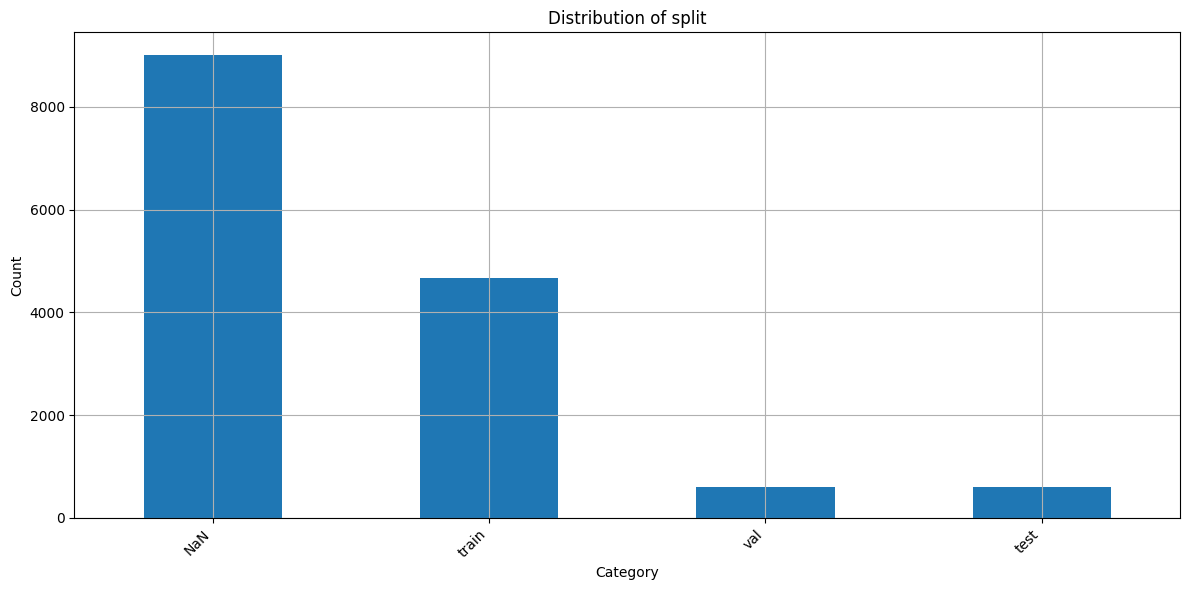

<Figure size 1400x600 with 0 Axes>

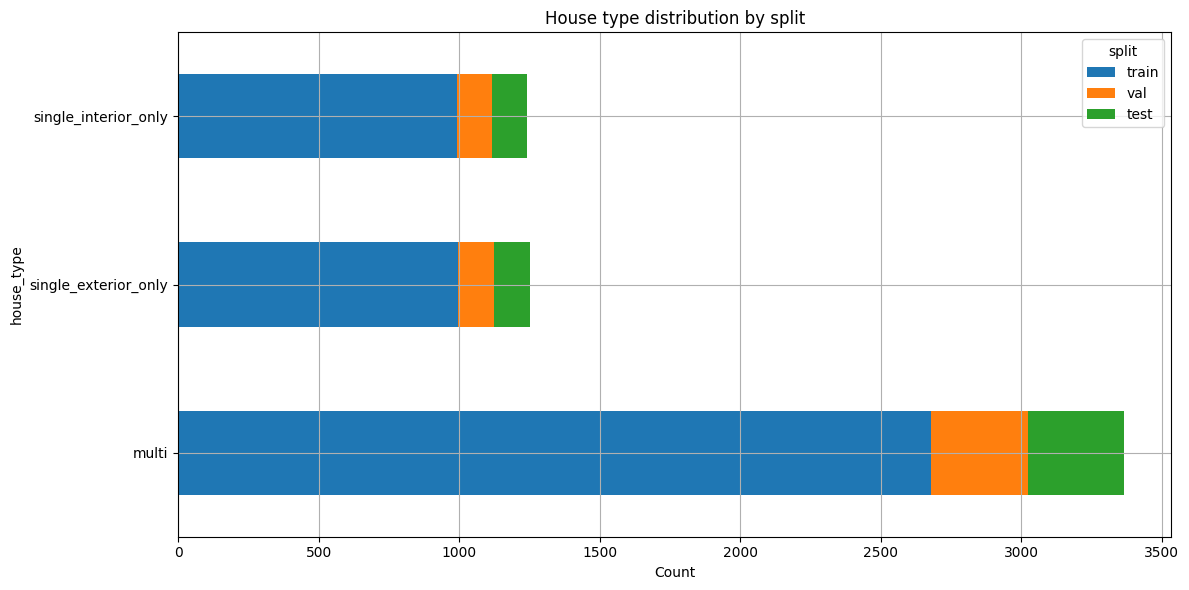

<Figure size 1400x600 with 0 Axes>

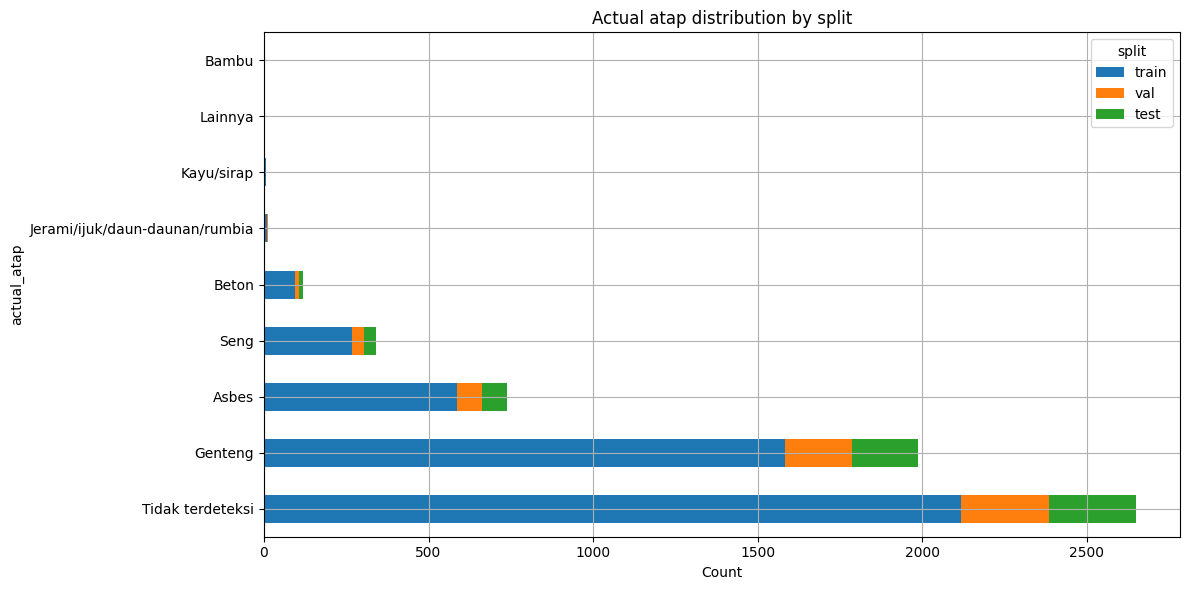

<Figure size 1400x600 with 0 Axes>

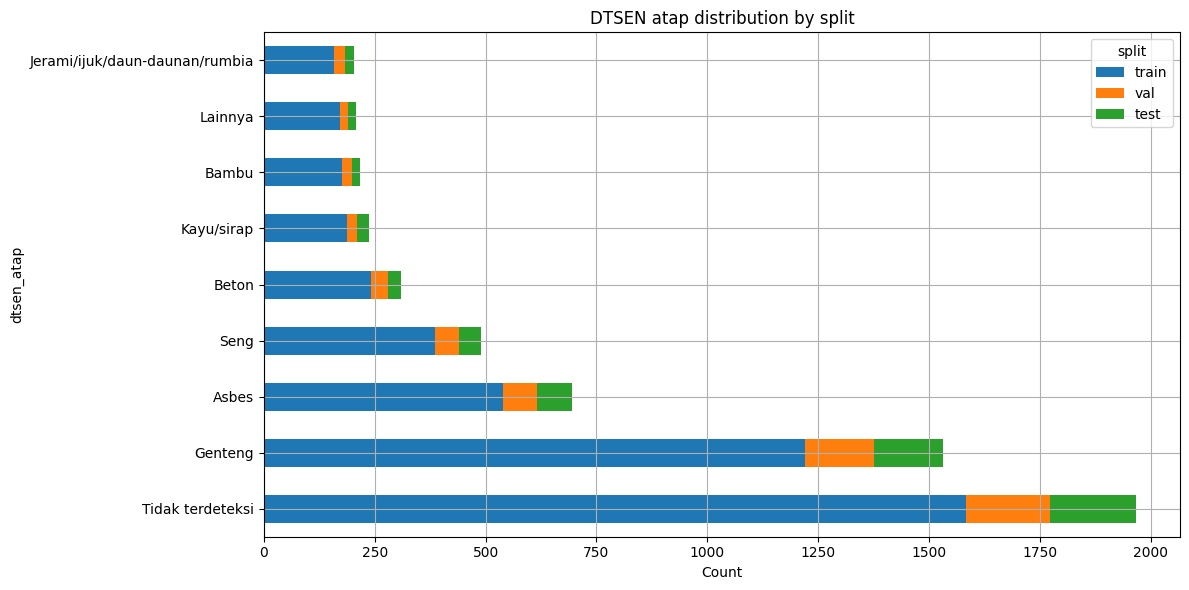

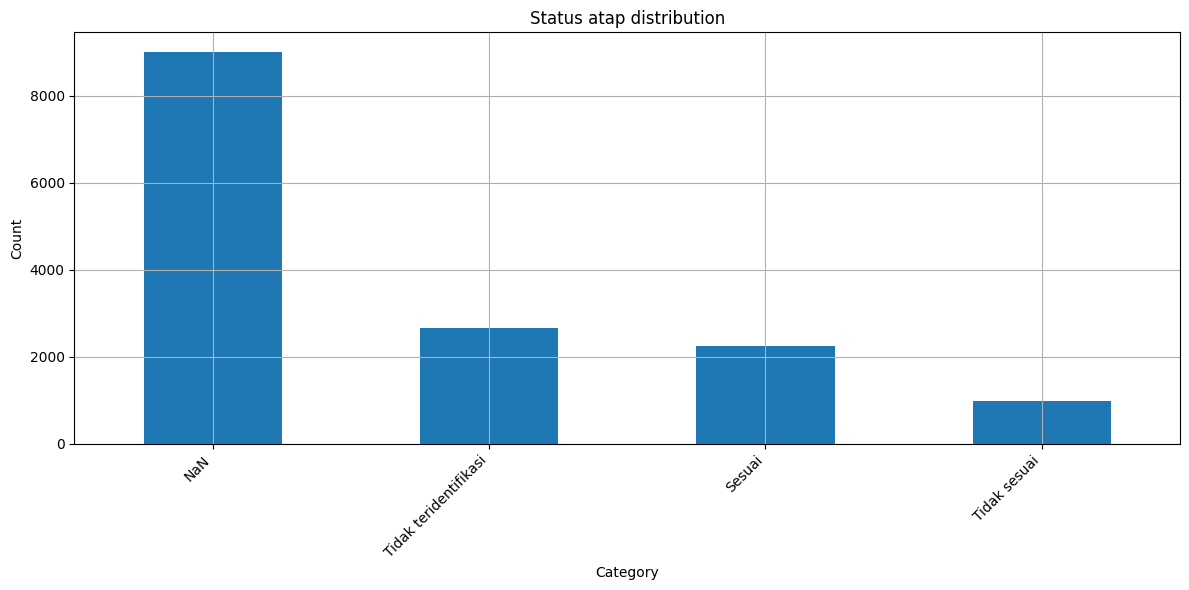

<Figure size 1400x600 with 0 Axes>

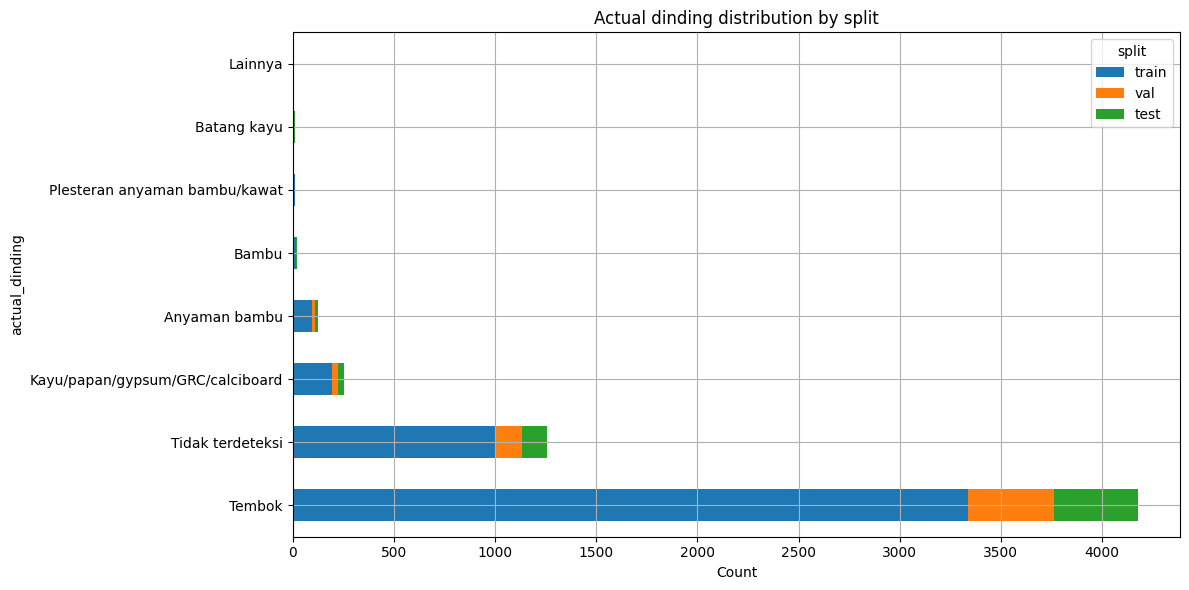

<Figure size 1400x600 with 0 Axes>

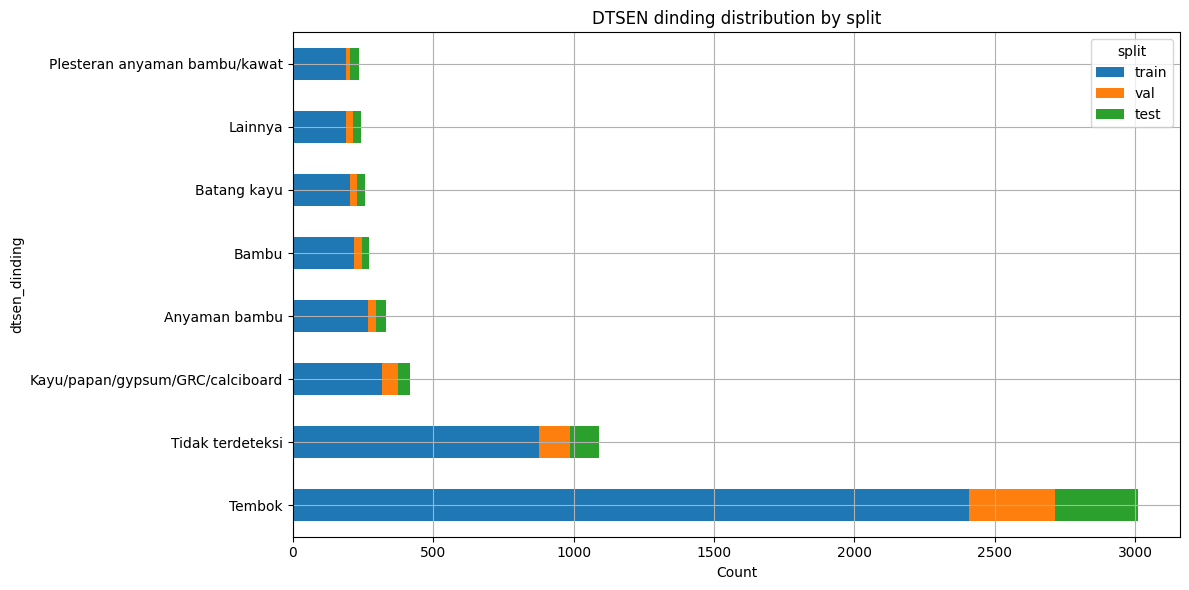

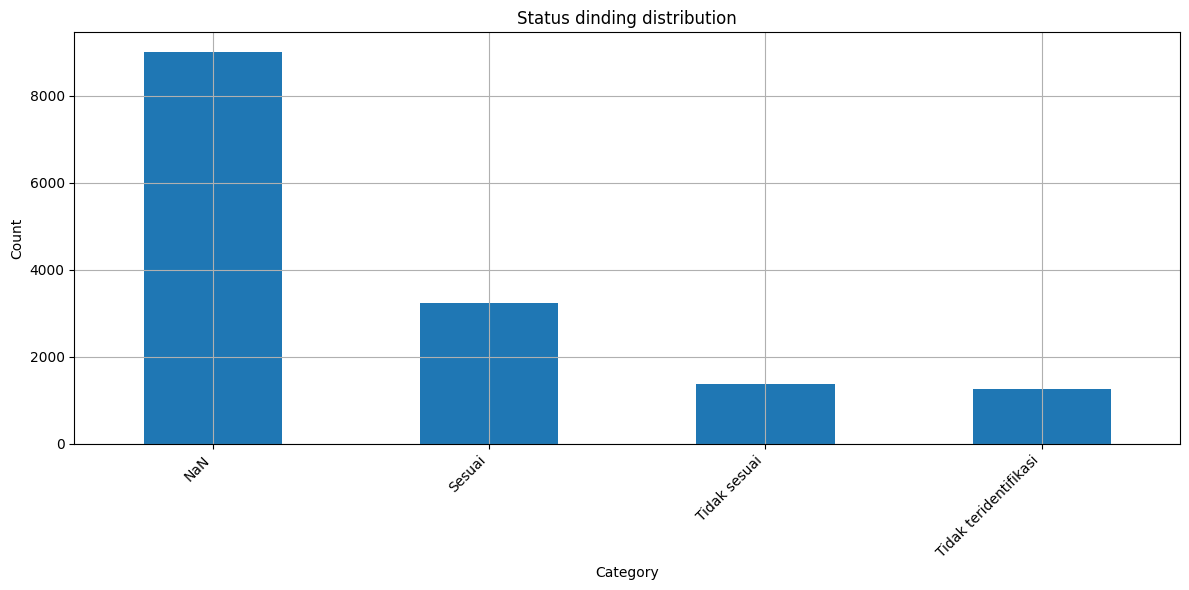

<Figure size 1400x600 with 0 Axes>

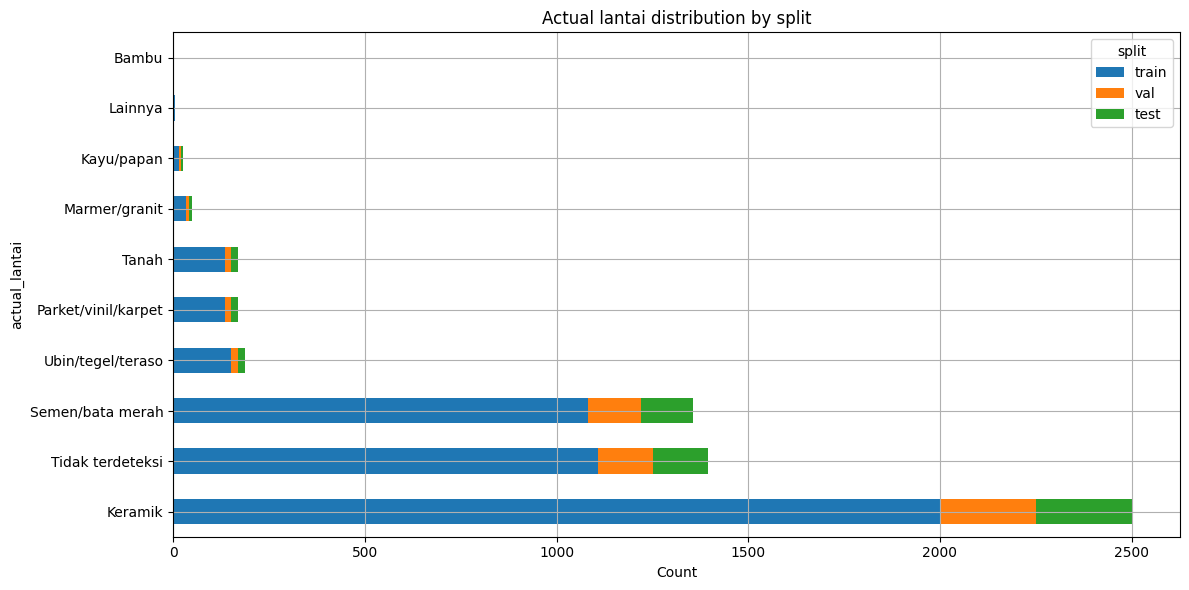

<Figure size 1400x600 with 0 Axes>

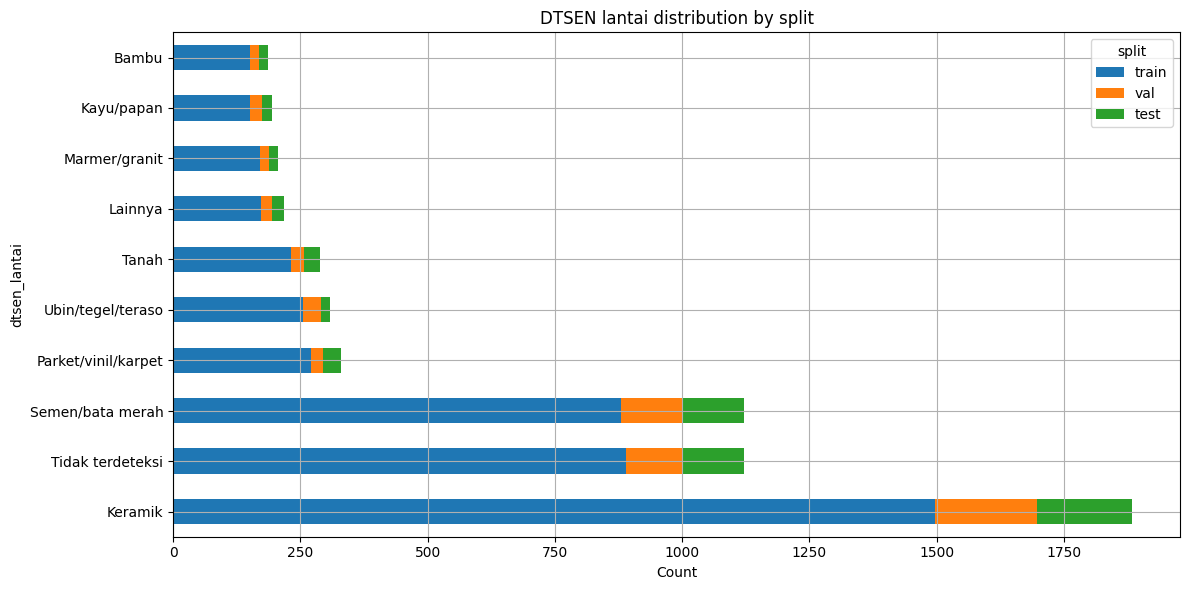

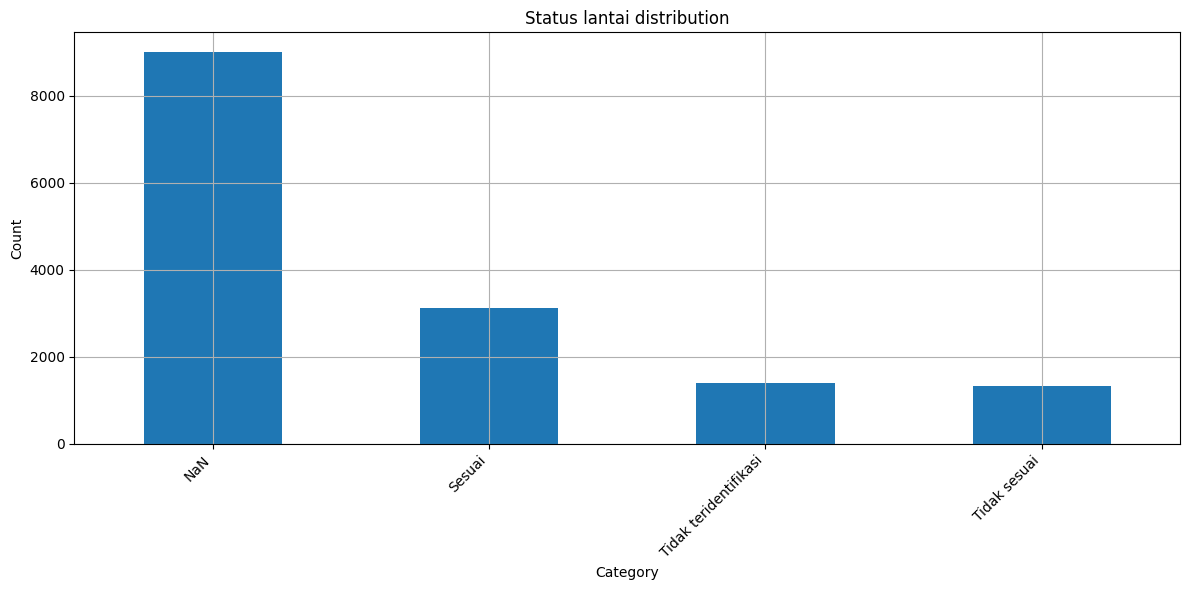

<Figure size 1400x4375 with 0 Axes>

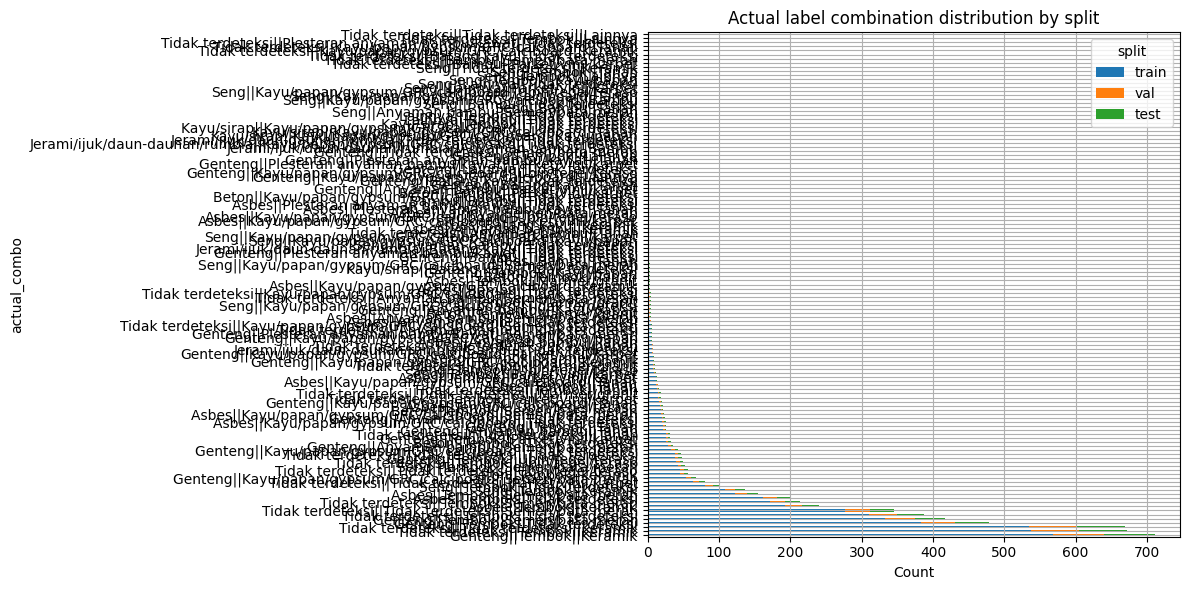

<Figure size 1400x19425 with 0 Axes>

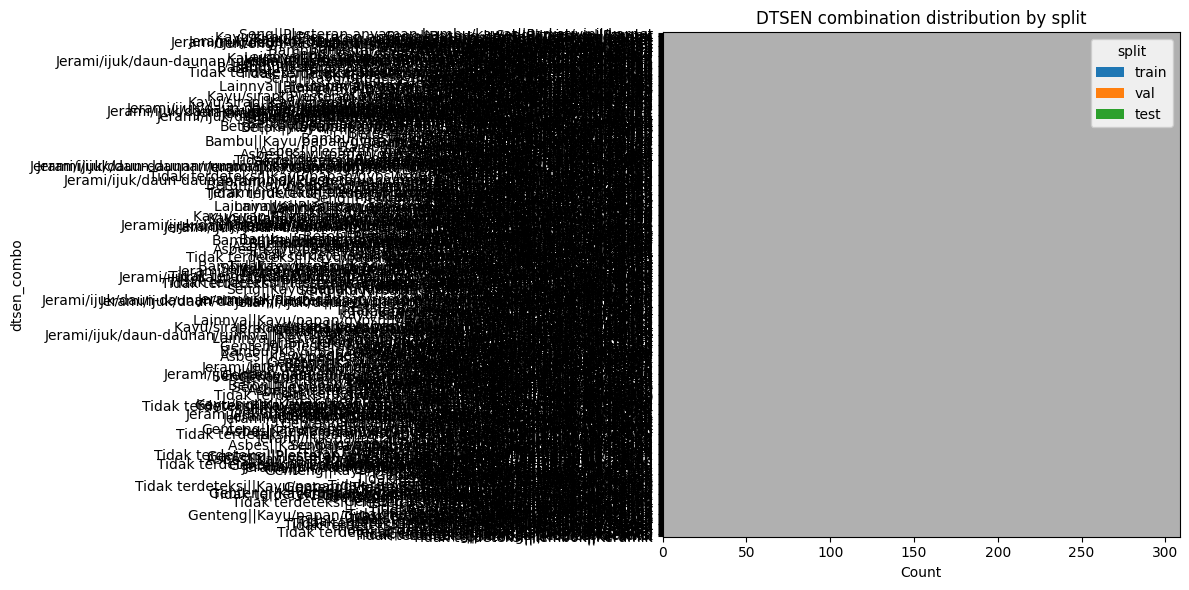

In [25]:
plot_bar(df["split"], "Distribution of split", "split_distribution.png")
plot_stacked_by_split(df, "house_type", "House type distribution by split", "house_type_by_split.png")

for comp in ["atap", "dinding", "lantai"]:
    plot_stacked_by_split(df, f"actual_{comp}", f"Actual {comp} distribution by split", f"actual_{comp}_by_split.png")
    plot_stacked_by_split(df, f"dtsen_{comp}", f"DTSEN {comp} distribution by split", f"dtsen_{comp}_by_split.png")
    plot_bar(df[f"status_{comp}"], f"Status {comp} distribution", f"status_{comp}_distribution.png")

plot_stacked_by_split(df, "actual_combo", "Actual label combination distribution by split", "actual_combo_by_split.png")
plot_stacked_by_split(df, "dtsen_combo", "DTSEN combination distribution by split", "dtsen_combo_by_split.png")


In [26]:
summary_json = {
    "total_records": int(len(df)),
    "split_distribution": split_distribution,
    "house_type_distribution_by_split": house_type_distribution_by_split,
    "actual_label_global_distribution": actual_label_global,
    "actual_label_by_split": actual_label_by_split,
    "dtsen_global_distribution": dtsen_label_global,
    "dtsen_by_split": dtsen_label_by_split,
    "status_distribution_by_split": status_distribution_by_split,
    "actual_combo_by_split": actual_combo_by_split,
    "dtsen_combo_by_split": dtsen_combo_by_split,
}

with open(OUTPUT_DIR / "eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_json, f, ensure_ascii=False, indent=2)

summary_json

{'total_records': 14861,
 'split_distribution': {'NaN': 9003, 'train': 4667, 'val': 598, 'test': 593},
 'house_type_distribution_by_split': {'train': {'multi': 2680,
   'single_exterior_only': 995,
   'single_interior_only': 992},
  'val': {'multi': 344,
   'single_exterior_only': 129,
   'single_interior_only': 125},
  'test': {'multi': 341,
   'single_exterior_only': 129,
   'single_interior_only': 123}},
 'actual_label_global_distribution': {'atap': {'Tidak terdeteksi': 6947,
   'Genteng': 3594,
   'Asbes': 1602,
   'Seng': 967,
   'Jerami/ijuk/daun-daunan/rumbia': 685,
   'Kayu/sirap': 524,
   'Beton': 507,
   'Bambu': 19,
   'Lainnya': 16},
  'dinding': {'Tembok': 8108,
   'Tidak terdeteksi': 4040,
   'Kayu/papan/gypsum/GRC/calciboard': 1459,
   'Anyaman bambu': 725,
   'Batang kayu': 334,
   'Bambu': 162,
   'Plesteran anyaman bambu/kawat': 21,
   'Lainnya': 12},
  'lantai': {'Tidak terdeteksi': 4474,
   'Keramik': 4067,
   'Semen/bata merah': 2794,
   'Parket/vinil/karpet': 1273

In [27]:
df.to_csv(OUTPUT_DIR / "mkn2_metadata_flattened.csv", index=False, encoding="utf-8-sig")
print(f"Saved outputs to: {OUTPUT_DIR}")

Saved outputs to: C:\Users\Lutfi\Documents\Project\AITF\rutilahu-vlm-etl\metadata_sample\eda_mkn2


In [28]:
rows = []

for rec in data:
    actual = rec.get("actual_label", {})

    rows.append({
        "house_type": rec.get("house_type"),
        "split": rec.get("split"),
        "actual_atap": actual.get("atap"),
        "actual_dinding": actual.get("dinding"),
        "actual_lantai": actual.get("lantai"),
    })

df = pd.DataFrame(rows)

print(f"Total data: {len(df):,}")
df.head()

Total data: 14,861


,house_type,split,actual_atap,actual_dinding,actual_lantai
0,multi,None,Tidak terdeteksi,Tembok,Ubin/tegel/teraso
1,multi,None,Genteng,Tembok,Semen/bata merah
2,multi,None,Asbes,Tembok,Semen/bata merah
3,multi,None,Genteng,Tembok,Keramik
4,multi,None,Asbes,Tembok,Semen/bata merah


In [29]:
# =====================================================
# COMBINATION KEY
# =====================================================

df["combo"] = (
    df["house_type"].astype(str)
    + " | "
    + df["actual_atap"].astype(str)
    + " | "
    + df["actual_dinding"].astype(str)
    + " | "
    + df["actual_lantai"].astype(str)
)

combo_counts = (
    df["combo"]
    .value_counts()
    .reset_index()
)

combo_counts.columns = ["combination", "count"]

top10_combo = combo_counts.head(10)

top10_combo

,combination,count
0,multi | Tidak terdeteksi | Tembok | Keramik,1323
1,single_interior_only | Tidak terdeteksi | Tida...,1004
2,single_interior_only | Tidak terdeteksi | Tida...,929
3,multi | Genteng | Tembok | Keramik,855
4,single_interior_only | Tidak terdeteksi | Tida...,784
5,multi | Genteng | Tembok | Semen/bata merah,728
6,single_exterior_only | Genteng | Tembok | Tida...,663
7,single_exterior_only | Tidak terdeteksi | Temb...,562
8,multi | Tidak terdeteksi | Tembok | Semen/bata...,502
9,multi | Asbes | Tembok | Keramik,419
